### Импорты

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller

### Загрузка двух рядов

In [5]:
airline = pd.read_csv('international-airline-passengers.csv')
airline['Month'] = pd.to_datetime(airline['Month'])
airline = airline.set_index('Month')['Count'].astype(float)

births = pd.read_csv('daily-total-female-births-in-cal.csv')
births['Date'] = pd.to_datetime(births['Date'])
births = births.set_index('Date')['Count'].astype(float)

airline.name = 'airline'
births.name = 'births'

### Быстрая проверка стационарности (ADF)

In [6]:
def adf_pvalue(series):
    series = series.dropna().astype(float)
    return adfuller(series.values)[1]

print('airline ADF p-value:', adf_pvalue(airline))
print('births ADF p-value:', adf_pvalue(births))

airline ADF p-value: 0.991880243437641
births ADF p-value: 5.243412990149865e-05


### Модели MA / EMA / DEMA / TEMA (one-step ahead)

Идея прогнозирования одинаковая: прогноз на момент `t` строим по истории `0..t-1`.

In [7]:
def forecast_ma(y, window):
    y = np.asarray(y, dtype=float)
    preds = np.full_like(y, np.nan, dtype=float)
    for t in range(1, len(y)):
        start = max(0, t - window)
        preds[t] = y[start:t].mean()
    return preds

def forecast_ema(y, span):
    y = np.asarray(y, dtype=float)
    alpha = 2.0 / (span + 1.0)
    preds = np.full_like(y, np.nan, dtype=float)
    s1 = y[0]
    for t in range(1, len(y)):
        preds[t] = s1
        s1 = alpha * y[t] + (1 - alpha) * s1
    return preds

def forecast_dema(y, span):
    y = np.asarray(y, dtype=float)
    alpha = 2.0 / (span + 1.0)
    preds = np.full_like(y, np.nan, dtype=float)
    s1 = y[0]
    s2 = y[0]
    for t in range(1, len(y)):
        preds[t] = 2 * s1 - s2
        s1 = alpha * y[t] + (1 - alpha) * s1
        s2 = alpha * s1 + (1 - alpha) * s2
    return preds

def forecast_tema(y, span):
    y = np.asarray(y, dtype=float)
    alpha = 2.0 / (span + 1.0)
    preds = np.full_like(y, np.nan, dtype=float)
    s1 = y[0]
    s2 = y[0]
    s3 = y[0]
    for t in range(1, len(y)):
        preds[t] = 3 * s1 - 3 * s2 + s3
        s1 = alpha * y[t] + (1 - alpha) * s1
        s2 = alpha * s1 + (1 - alpha) * s2
        s3 = alpha * s2 + (1 - alpha) * s3
    return preds

### Метрика и подбор параметров

In [8]:
import math

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return math.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))

models = {
    'MA': ('param', forecast_ma),
    'EMA': ('param', forecast_ema),
    'DEMA': ('param', forecast_dema),
    'TEMA': ('param', forecast_tema)
}

def tune_and_evaluate(series, test_horizon, grid):
    y = series.values.astype(float)
    n = len(y)

    test_start = n - test_horizon
    tune_end = test_start

    train_end = int(tune_end * 0.7)
    val_end = tune_end

    rows = []
    best = {}

    for model_name, (_, func) in models.items():
        best_val = 1e18
        best_param = None

        for p in grid:
            preds = func(y, p)
            val_score = rmse(y[train_end:val_end], preds[train_end:val_end])
            if val_score < best_val:
                best_val = val_score
                best_param = p

        preds = func(y, best_param)
        test_score = rmse(y[test_start:], preds[test_start:])

        rows.append([model_name, best_param, best_val, test_score])
        best[model_name] = {'best_param': best_param, 'test_rmse': test_score}

    df = pd.DataFrame(rows, columns=['model', 'best_param', 'val_rmse', 'test_rmse']).sort_values('test_rmse')
    return df, test_start

### Эксперимент для нестационарного ряда (airline)

In [9]:
airline_results, airline_test_start = tune_and_evaluate(
    airline,
    test_horizon=12,
    grid=list(range(2, 31))
)

airline_results

,model,best_param,val_rmse,test_rmse
3,TEMA,2,46.762766,54.051761
2,DEMA,2,48.917272,56.585418
1,EMA,2,52.510087,61.942870
0,MA,2,57.525375,67.590988


### Эксперимент для стационарного ряда (births)

In [10]:
births_results, births_test_start = tune_and_evaluate(
    births,
    test_horizon=31,
    grid=list(range(2, 61))
)

births_results

,model,best_param,val_rmse,test_rmse
0,MA,23,7.246614,6.816258
1,EMA,12,7.175437,7.042747
2,DEMA,26,7.271257,7.122582
3,TEMA,36,7.331631,7.179380


### Визуализация прогноза лучшей модели

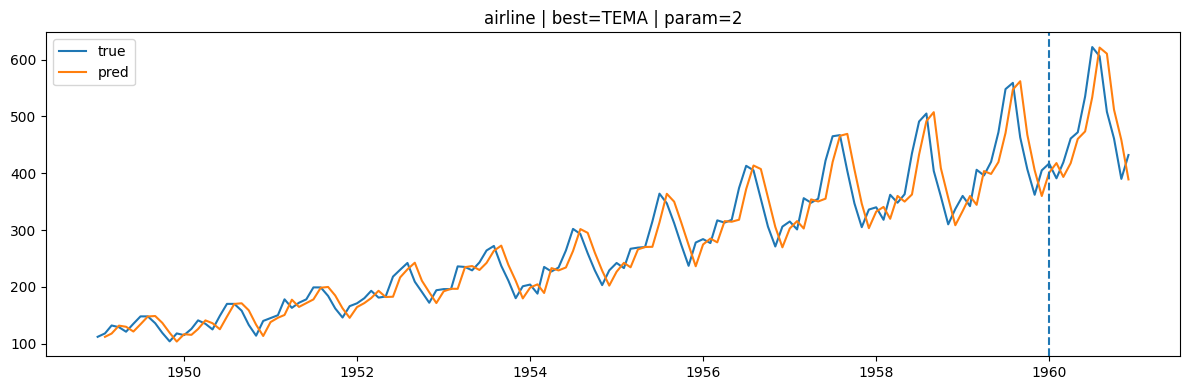

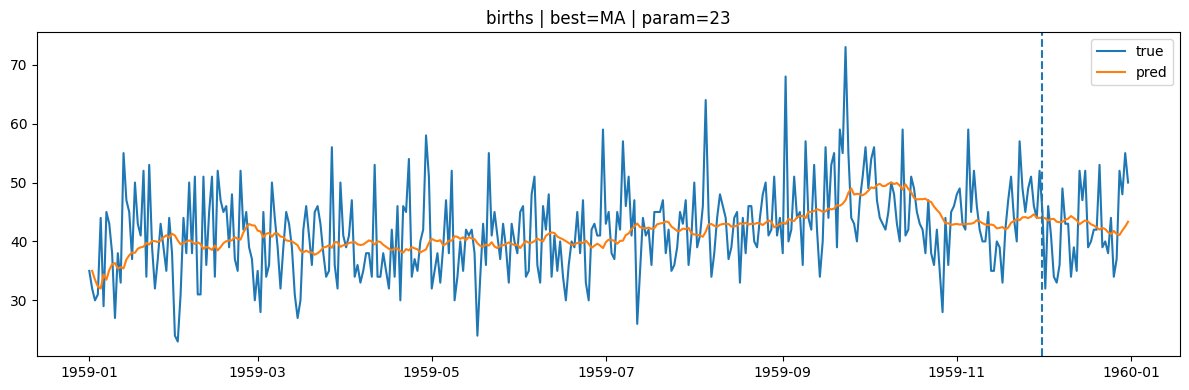

In [11]:
def plot_best(series, results_df, test_start):
    y = series.values.astype(float)
    best_model = results_df.iloc[0]['model']
    best_param = int(results_df.iloc[0]['best_param'])

    func = models[best_model][1]
    preds = func(y, best_param)

    idx = series.index

    plt.figure(figsize=(12, 4))
    plt.plot(idx, y, label='true')
    plt.plot(idx, preds, label='pred')
    plt.axvline(idx[test_start], linestyle='--')
    plt.title(series.name + ' | best=' + best_model + ' | param=' + str(best_param))
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_best(airline, airline_results, airline_test_start)
plot_best(births, births_results, births_test_start)

## Итоговый вывод

В ходе работы был проведён эксперимент с моделями сглаживания класса MA (MA, EMA, DEMA, TEMA) на двух временных рядах разного типа: нестационарном (`international airline passengers`) и стационарном (`daily total female births`). Для каждой модели подбирались оптимальные параметры по валидационной части первых наблюдений ряда, после чего выполнялось прогнозирование на последнем участке данных. Качество прогнозов оценивалось с помощью метрики RMSE.

Для нестационарного ряда наименьшее значение RMSE показала модель **TEMA** с параметром 2. Это объясняется тем, что тройное экспоненциальное сглаживание уменьшает запаздывание прогноза и позволяет лучше отслеживать изменения уровня ряда при наличии тренда и сезонных колебаний. Простые модели сглаживания в этом случае уступают из-за более выраженного лага.

Для стационарного ряда лучшей оказалась модель **MA** с окном 23. Поскольку ряд колеблется вокруг постоянного среднего и не содержит тренда, основная задача сводится к сглаживанию шума, с чем простое скользящее среднее справляется наиболее эффективно. Более сложные экспоненциальные модели не дали улучшения качества прогноза.

Таким образом, эксперимент показал, что оптимальная модель сглаживания зависит от типа временного ряда: для нестационарных рядов предпочтительны модели с уменьшенным лагом (DEMA, TEMA), а для стационарных - более простые методы сглаживания (MA).
